# Partie : Analyse exploratoire:

## Chargement:

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("players_clean1.csv", sep=",", encoding="utf-8-sig")

## Statistiques descriptives:

In [28]:
# Statistiques descriptives générales
df.describe()

,age,matches_played,goals,own_goals,assists,yellow_cards,red_cards,valeur_marchande_eur,nat_Brazil,nat_England,nat_Spain,nat_France,nat_Argentina,nat_Germany,valeur_marchande_log,age_scaled,matches_played_scaled,goals_scaled,assists_scaled,valeur_marchande_log_scaled
count,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1.992000e+03,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,23.963855,34.129518,4.547691,0.058735,3.885542,4.243976,0.116466,1.681913e+07,0.078313,0.070783,0.063253,0.061245,0.054719,0.041165,15.688374,-0.034316,0.000971,0.055672,0.070295,-0.020766
std,3.542481,11.260501,5.580400,0.251692,3.577084,3.042593,0.363434,2.177909e+07,0.268731,0.256527,0.243479,0.239839,0.227488,0.198721,1.688812,0.990295,0.987762,1.013327,0.999224,1.027657
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.918397,-2.540148,-2.992844,-0.770128,-1.015094,-2.314830
25%,21.000000,27.000000,1.000000,0.000000,1.000000,2.000000,0.000000,2.500000e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.731802,-0.862857,-0.624425,-0.588542,-0.735753,-0.602849
50%,24.000000,35.000000,3.000000,0.000000,3.000000,4.000000,0.000000,9.000000e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.012735,-0.024212,0.077329,-0.225368,-0.177073,0.176610
75%,26.000000,41.000000,6.000000,0.000000,6.000000,6.000000,0.000000,2.500000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.034386,0.534885,0.603645,0.319392,0.660949,0.798294
max,37.000000,68.000000,59.000000,2.000000,28.000000,20.000000,2.000000,2.000000e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.113828,3.609919,2.972064,9.943488,6.806439,2.063652


In [29]:
# Statistiques ciblées sur les variables clés
colonnes_cles = ["age", "matches_played", "goals", "assists", "valeur_marchande_eur"]
df[colonnes_cles].describe()

,age,matches_played,goals,assists,valeur_marchande_eur
count,1992.000000,1992.000000,1992.000000,1992.000000,1.992000e+03
mean,23.963855,34.129518,4.547691,3.885542,1.681913e+07
std,3.542481,11.260501,5.580400,3.577084,2.177909e+07
min,15.000000,0.000000,0.000000,0.000000,1.500000e+05
25%,21.000000,27.000000,1.000000,1.000000,2.500000e+06
50%,24.000000,35.000000,3.000000,3.000000,9.000000e+06
75%,26.000000,41.000000,6.000000,6.000000,2.500000e+07
max,37.000000,68.000000,59.000000,28.000000,2.000000e+08


In [30]:
# Répartition par poste
df["poste"].value_counts()

poste
Right Winger          436
Right Midfield        420
Right-Back            225
Central Midfield      223
Left-Back             145
Attacking Midfield    144
Centre-Forward        125
Centre-Back           125
Defensive Midfield     74
Left Winger            50
Left Midfield          25
Name: count, dtype: int64

In [31]:
# Répartition par nationalité (top 5)
df["nationalite"].value_counts().head(5)

nationalite
Brazil       156
England      141
Spain        126
France       122
Argentina    109
Name: count, dtype: int64

## Histogrammes:

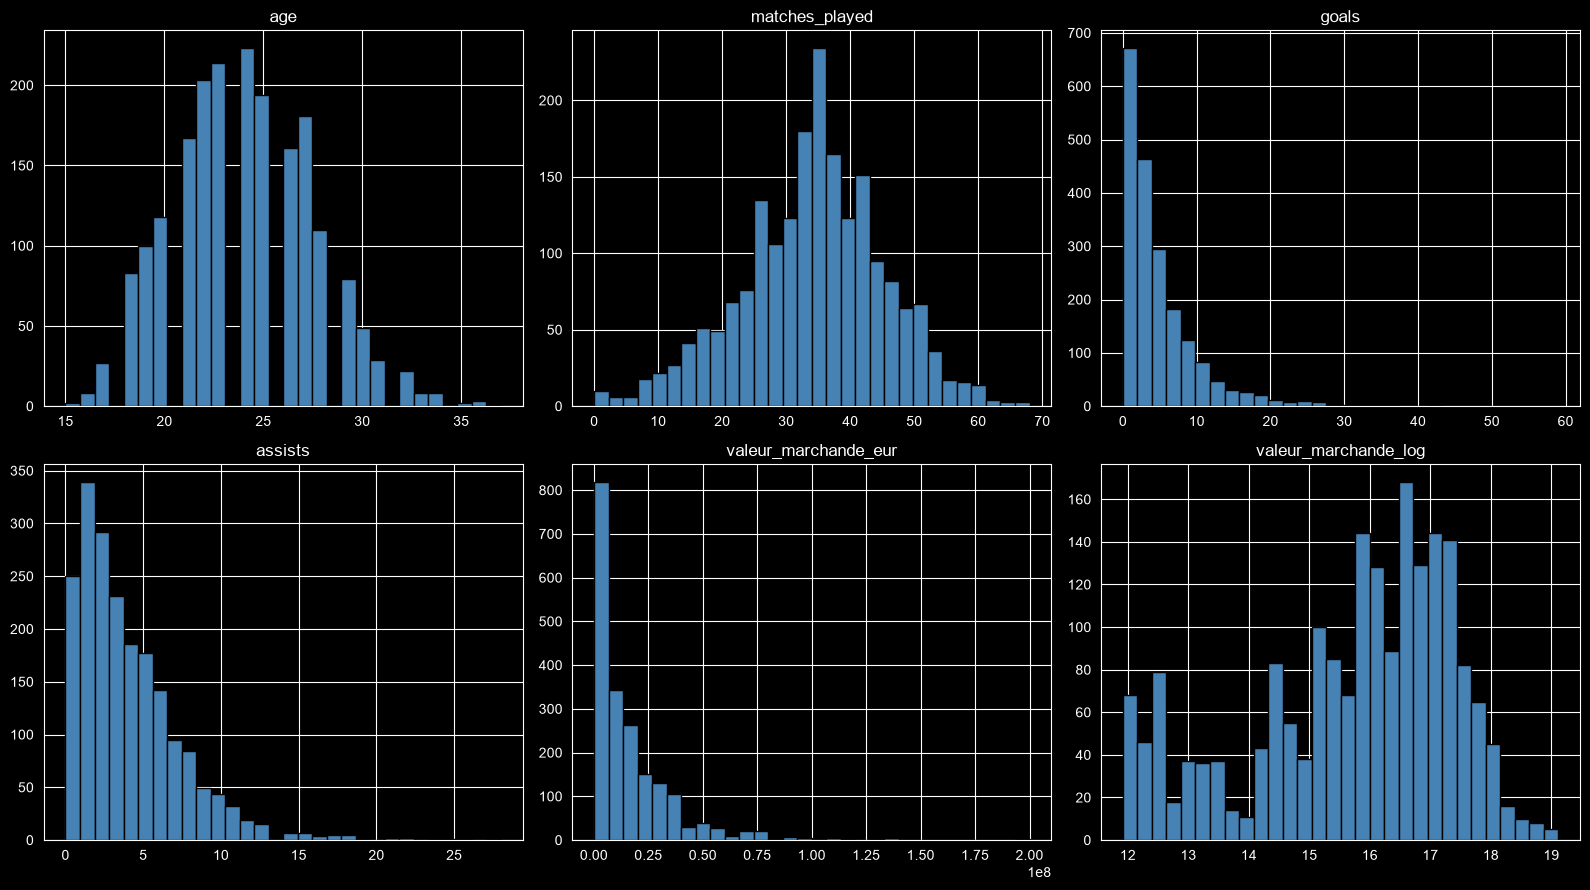

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colonnes = ["age", "matches_played", "goals", "assists", "valeur_marchande_eur", "valeur_marchande_log"]

for ax, col in zip(axes.flatten(), colonnes):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="black")
    ax.set_title(col)

plt.tight_layout()
plt.savefig("histogrammes.png", dpi=150)
plt.show()

## Boxplots :

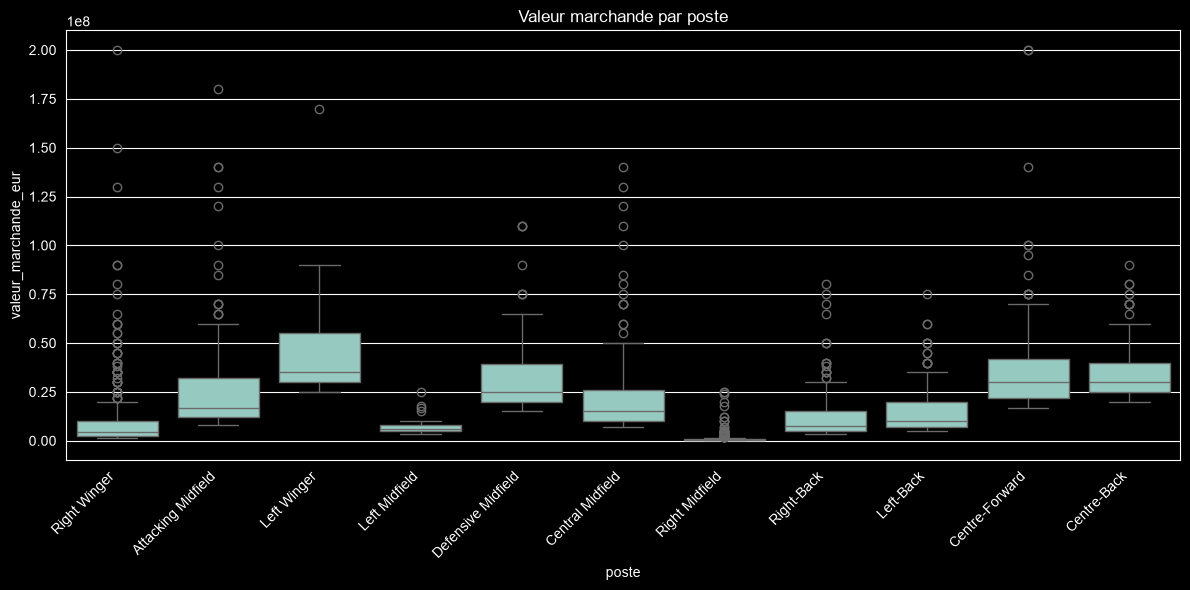

In [33]:
# Boxplot de la valeur marchande par poste
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="poste", y="valeur_marchande_eur")
plt.xticks(rotation=45, ha="right")
plt.title("Valeur marchande par poste")
plt.tight_layout()
plt.savefig("boxplot_poste.png", dpi=150)
plt.show()

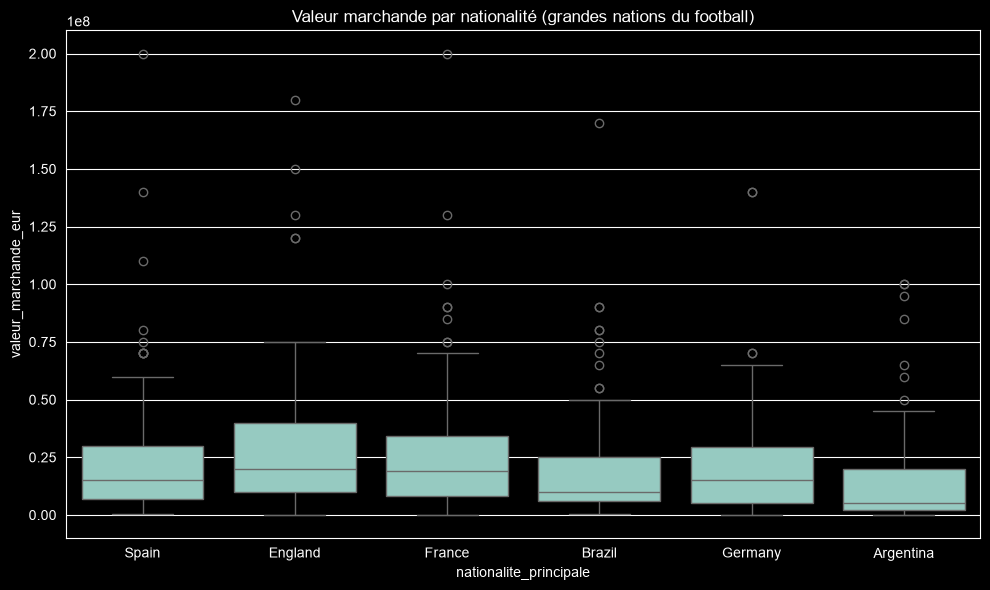

In [39]:
#Boxplot de la valeur marchande par nationalité (grandes nations)
nat_cols = ["nat_Brazil", "nat_England", "nat_Spain", "nat_France", "nat_Argentina", "nat_Germany"]

df_grandes_nations = df[df[nat_cols].sum(axis=1) == 1].copy()
df_grandes_nations["nationalite_principale"] = df_grandes_nations[nat_cols].idxmax(axis=1).str.replace("nat_", "")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grandes_nations, x="nationalite_principale", y="valeur_marchande_eur")
plt.title("Valeur marchande par nationalité (grandes nations du football)")
plt.tight_layout()
plt.savefig("boxplot_nationalite.png", dpi=150)
plt.show()

## Matrice de corrélation :

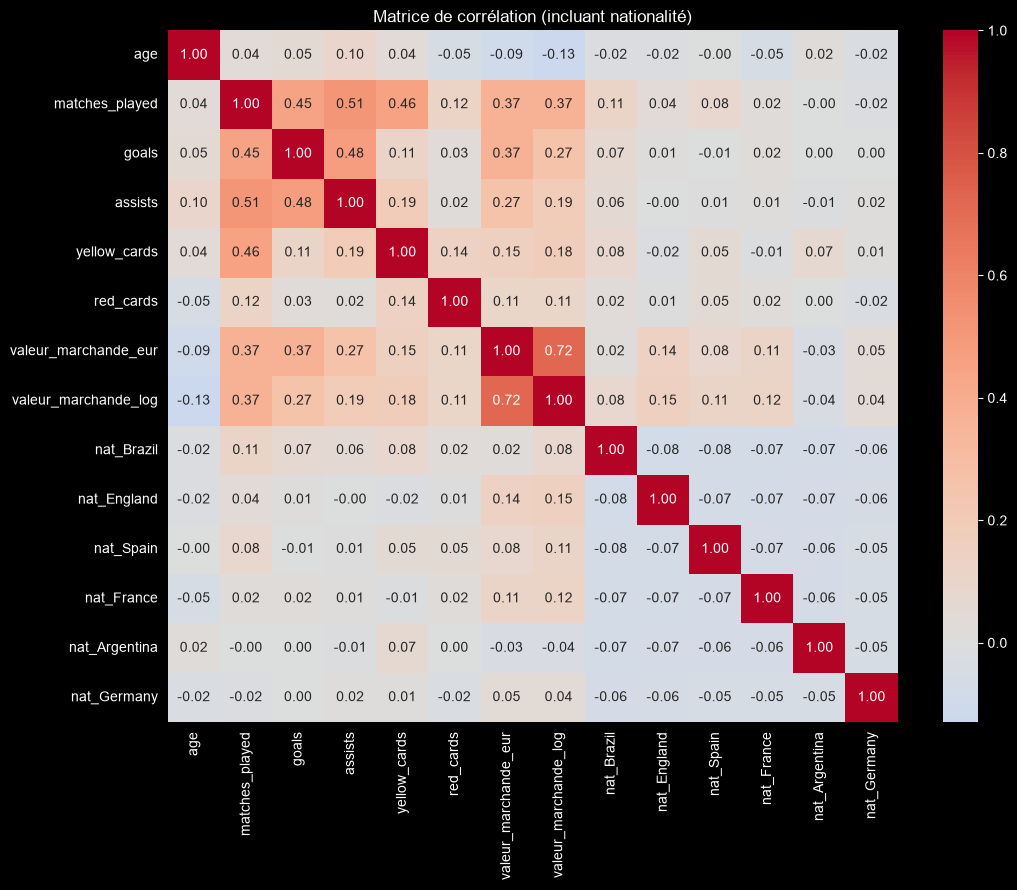

In [35]:
colonnes_corr = ["age", "matches_played", "goals", "assists",
                  "yellow_cards", "red_cards", "valeur_marchande_eur", "valeur_marchande_log"]
nat_cols = ["nat_Brazil", "nat_England", "nat_Spain", "nat_France", "nat_Argentina", "nat_Germany"]
colonnes_corr_completes = colonnes_corr + nat_cols

matrice_corr = df[colonnes_corr_completes].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matrice de corrélation (incluant nationalité)")
plt.tight_layout()
plt.savefig("matrice_correlation.png", dpi=150)
plt.show()

## Analyse des variables importantes :

In [36]:
# Corrélation de chaque variable avec la cible (valeur marchande log), nationalité incluse
correlations = df[colonnes_corr_completes].corr()["valeur_marchande_log"].sort_values(ascending=False)
print(correlations)

valeur_marchande_log    1.000000
valeur_marchande_eur    0.718334
matches_played          0.370864
goals                   0.266849
assists                 0.192336
yellow_cards            0.177781
nat_England             0.149841
nat_France              0.124782
nat_Spain               0.110909
red_cards               0.107435
nat_Brazil              0.084874
nat_Germany             0.042269
nat_Argentina          -0.036585
age                    -0.129870
Name: valeur_marchande_log, dtype: float64


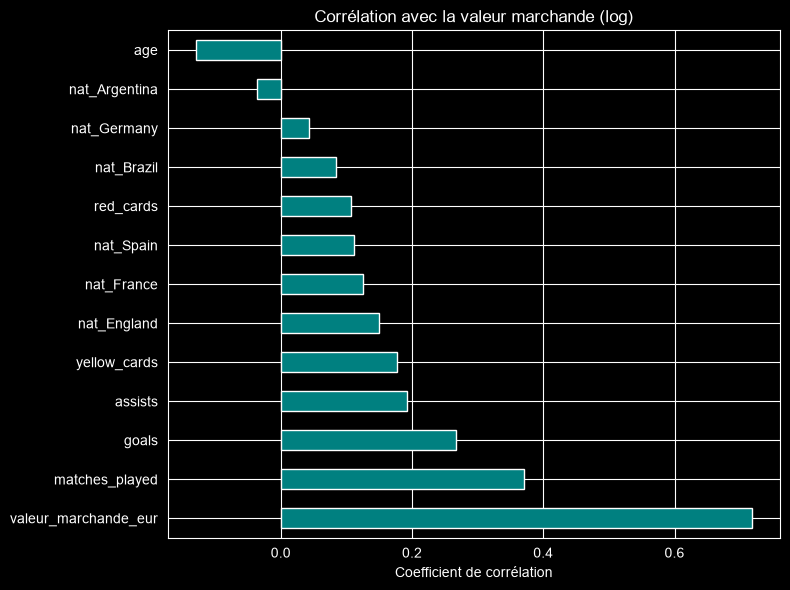

In [37]:
# Visualisation en barres
plt.figure(figsize=(8, 6))
correlations.drop("valeur_marchande_log").plot(kind="barh", color="teal")
plt.title("Corrélation avec la valeur marchande (log)")
plt.xlabel("Coefficient de corrélation")
plt.tight_layout()
plt.savefig("variables_importantes.png", dpi=150)
plt.show()

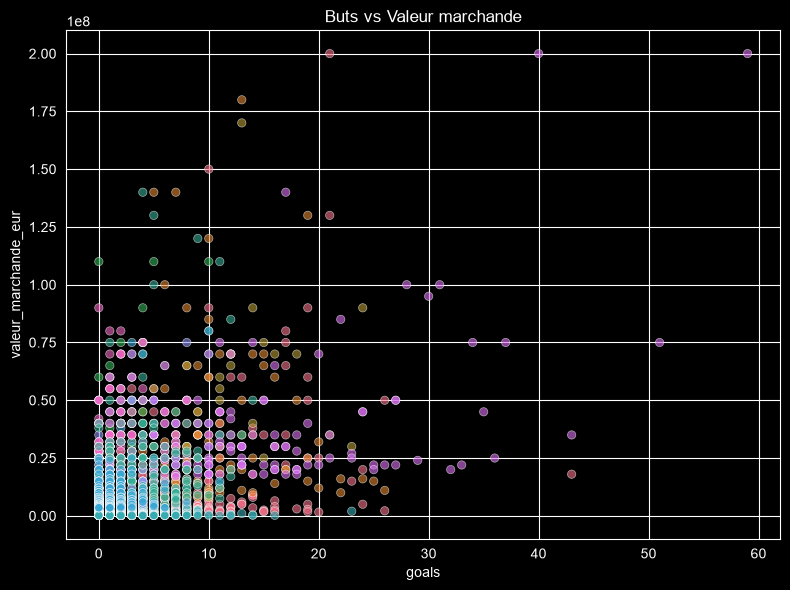

In [38]:
# Scatter buts vs valeur marchande
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="goals", y="valeur_marchande_eur", hue="poste", alpha=0.6, legend=False)
plt.title("Buts vs Valeur marchande")
plt.tight_layout()
plt.savefig("goals_vs_valeur.png", dpi=150)
plt.show()